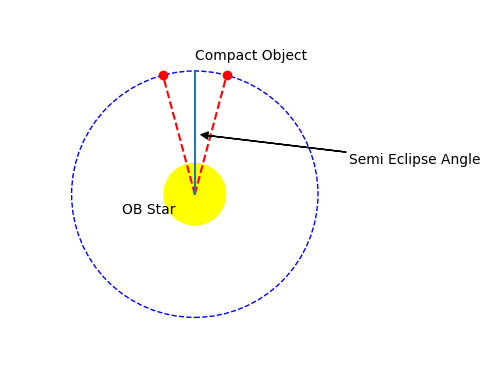

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters for the diagram
star_radius = 1
compact_orbit_radius = 4
semi_eclipse_angle = 15  # degrees

# Create figure and axis
fig, ax = plt.subplots()

# Plot the normal star
star = plt.Circle((0, 0), star_radius, color='yellow', label='Normal Star')
ax.add_artist(star)

# Plot the compact object's orbit
orbit = plt.Circle((0, 0), compact_orbit_radius, color='blue', fill=False, linestyle='--', label='Compact Object Orbit')
ax.add_artist(orbit)

# Plot the compact object at the point of eclipse entry and exit
entry_x = compact_orbit_radius * np.sin(np.radians(semi_eclipse_angle))
entry_y = compact_orbit_radius * np.cos(np.radians(semi_eclipse_angle))
exit_x = compact_orbit_radius * np.sin(np.radians(-semi_eclipse_angle))
exit_y = compact_orbit_radius * np.cos(np.radians(-semi_eclipse_angle))

ax.plot([entry_x, exit_x], [entry_y, exit_y], 'ro', label='Eclipse Entry/Exit')

# Plot lines indicating the semi eclipse angle
ax.plot([0, entry_x], [0, entry_y], 'r--')
ax.plot([0, exit_x], [0, exit_y], 'r--')
ax.plot([0, 0], [0, compact_orbit_radius * np.cos(np.radians(0))])

# Annotate the semi eclipse angle
ax.annotate('Semi Eclipse Angle',
            xy=(0.2, (entry_y + exit_y)/4),
            xytext=(compact_orbit_radius + 1, 1),
            arrowprops=dict(facecolor='black', shrink=1, width=0.1, headwidth=5, headlength=5))

# Annotate the components
ax.text(-star_radius - 0.5, -0.5, 'OB Star', horizontalalignment='center', verticalalignment='center')
ax.text(0, compact_orbit_radius + 0.5, 'Compact Object', verticalalignment='center')

# Set limits and aspect
ax.set_xlim(-compact_orbit_radius - 2, compact_orbit_radius + 2)
ax.set_ylim(-compact_orbit_radius - 2, compact_orbit_radius + 2)
ax.set_aspect('equal')

# Hide axes
ax.axis('off')

# Add legend
# ax.legend()

# Show plot
# plt.title('Semi Eclipse Angle in a High Mass X-ray Binary')
plt.show()

# Save figure as PNG
# fig.savefig("/mnt/data/semi_eclipse_angle_HMXB.png")


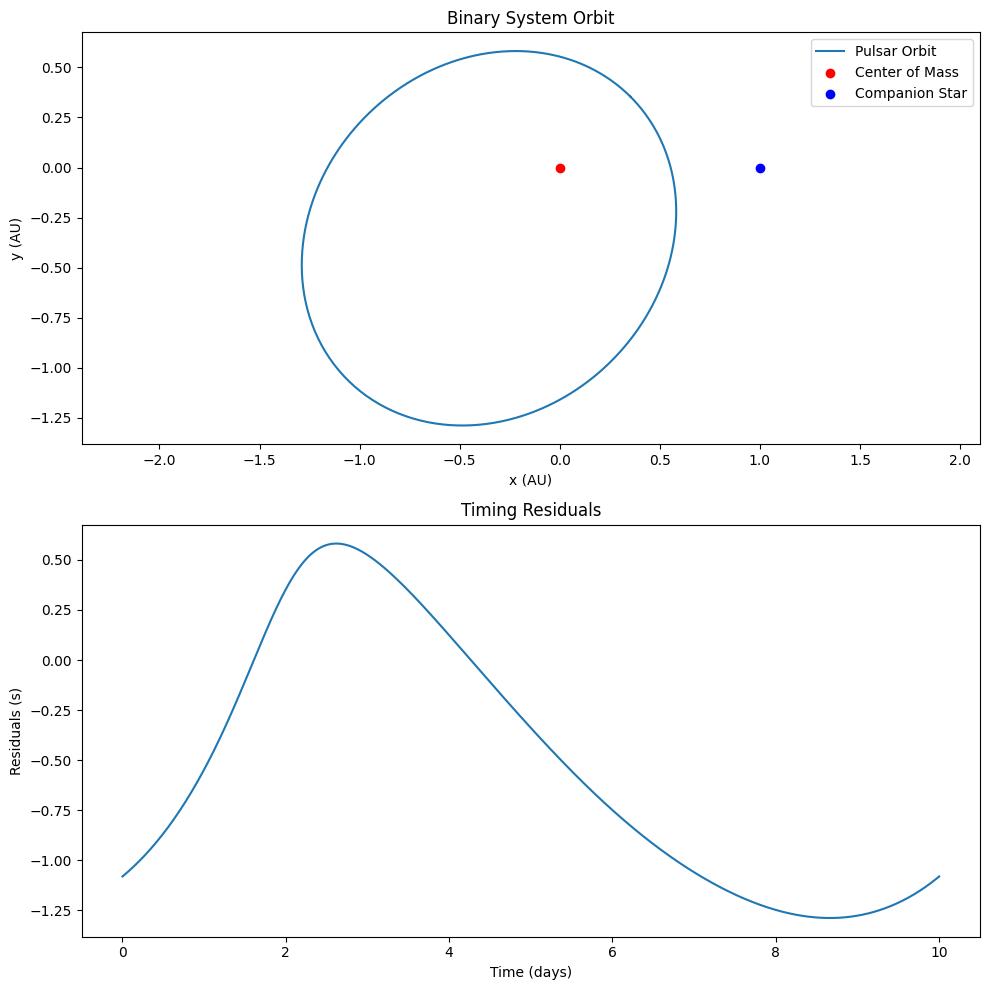

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time array
time = np.linspace(0, 10, 1000)

# Define the orbital parameters for the example (values are illustrative)
P_orb = 10  # Orbital period
e = 0.5  # Eccentricity
a_p = 1  # Semi-major axis
omega = np.pi / 4  # Longitude of periastron
T_0 = 2  # Time of periastron passage

# Calculate the mean anomaly
M = 2 * np.pi / P_orb * (time - T_0)

# Use the mean anomaly to find the eccentric anomaly (iteratively solve Kepler's equation)
E = M
for i in range(5):
    E = M + e * np.sin(E)

# True anomaly
theta = 2 * np.arctan2(np.sqrt(1+e) * np.sin(E/2), np.sqrt(1-e) * np.cos(E/2))

# Pulsar's distance from the center of mass
r = a_p * (1 - e * np.cos(E))

# Pulsar's velocity in the line of sight
v_r = (2 * np.pi * a_p / P_orb) / (1 - e * np.cos(E)) * e * np.sin(theta + omega)

# Timing residuals (simplified model)
residuals = r * np.sin(theta + omega)

# Plotting the binary orbit schematic
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Orbit plot
ax = axs[0]
theta_plot = np.linspace(0, 2*np.pi, 500)
r_plot = a_p * (1 - e**2) / (1 + e * np.cos(theta_plot))
x_orbit = r_plot * np.cos(theta_plot + omega)
y_orbit = r_plot * np.sin(theta_plot + omega)
ax.plot(x_orbit, y_orbit, label='Pulsar Orbit')
ax.scatter(0, 0, color='red', zorder=5, label='Center of Mass')
ax.scatter(a_p, 0, color='blue', zorder=5, label='Companion Star')
ax.legend()
ax.set_title('Binary System Orbit')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.axis('equal')

# Timing residuals plot
ax = axs[1]
ax.plot(time, residuals)
ax.set_title('Timing Residuals')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Residuals (s)')

plt.tight_layout()
plt.show()

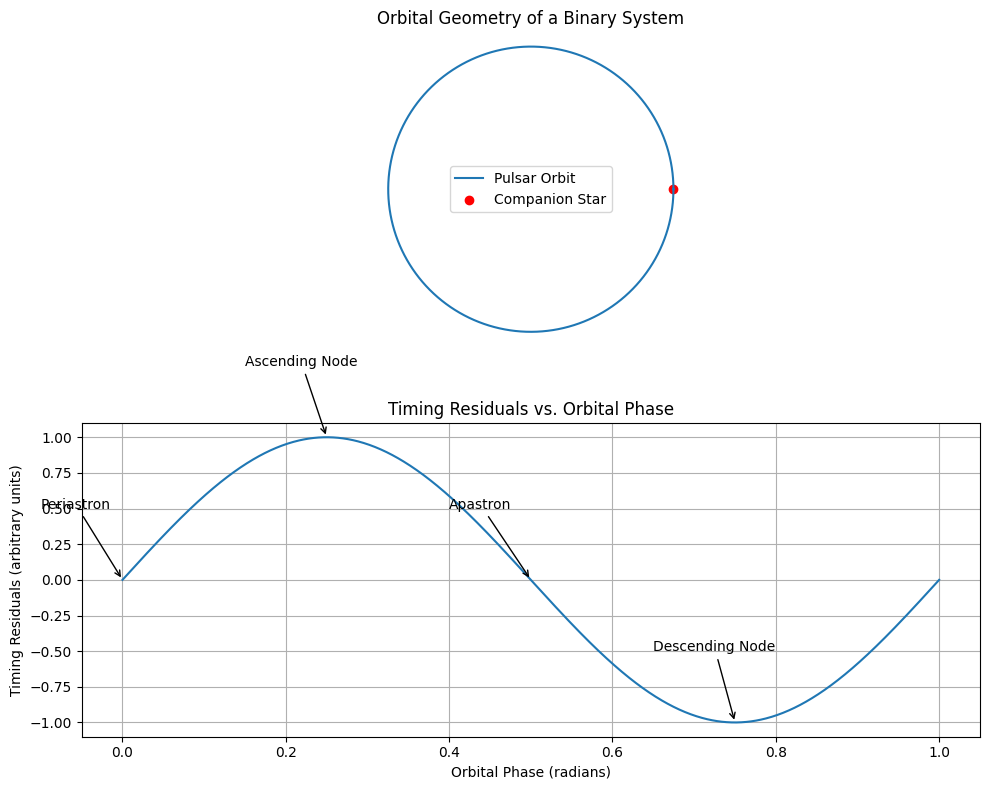

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define the orbital parameters
orbital_period = 1.0  # Orbital period in arbitrary units
amplitude = 1.0  # Amplitude of the timing residuals in arbitrary units

# Define the time array
time = np.linspace(0, orbital_period, 1000)

# Calculate the orbital phase
orbital_phase = 2 * np.pi * time / orbital_period

# Calculate the timing residuals (sinusoidal variation due to orbital motion)
timing_residuals = amplitude * np.sin(orbital_phase)

# Create the figure
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot the orbital diagram
ax[0].plot(np.cos(orbital_phase), np.sin(orbital_phase), label="Pulsar Orbit")
ax[0].scatter(1, 0, color='red', label="Companion Star")
# ax[0].annotate('Periastron', xy=(1, 0), xytext=(1.1, 0.1),
#                arrowprops=dict(facecolor='black', arrowstyle='->'))
# ax[0].annotate('Apastron', xy=(-1, 0), xytext=(-1.3, -0.1),
#                arrowprops=dict(facecolor='black', arrowstyle='->'))
ax[0].set_aspect('equal')
ax[0].set_title("Orbital Geometry of a Binary System")
ax[0].set_xlabel("x (arbitrary units)")
ax[0].set_ylabel("y (arbitrary units)")
ax[0].legend()

# Plot the timing residuals
ax[1].plot(time, timing_residuals, label="Timing Residuals")
ax[1].set_title("Timing Residuals vs. Orbital Phase")
ax[1].set_xlabel("Orbital Phase (radians)")
ax[1].set_ylabel("Timing Residuals (arbitrary units)")
ax[1].grid(True)

# Add annotations for key points in the orbit
phases = [0, np.pi/2, np.pi, 3*np.pi/2]
labels = ["Periastron", "Ascending Node", "Apastron", "Descending Node"]
for phase, label in zip(phases, labels):
    ax[1].annotate(label, xy=(phase / (2 * np.pi), amplitude * np.sin(phase)),
                   xytext=(phase / (2 * np.pi) - 0.1, amplitude * np.sin(phase) + 0.5),
                   arrowprops=dict(facecolor='black', arrowstyle='->'))

ax[0].axis('off')
plt.tight_layout()
plt.show()
